<a href="https://colab.research.google.com/github/Maartzzz/Modelado-Platano/blob/main/Modelado_Colori_Brix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BLOQUE 1
# LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RepeatedKFold

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.base import clone

from sklearn.cross_decomposition import PLSRegression

from sklearn.svm import SVR

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

print("Librerías cargadas.")

Librerías cargadas.


In [ ]:
# ============================================================
# BLOQUE 2
# CARGA DEL DATASET
# ============================================================

# Colorimetría
color = pd.read_csv(
    "Colorimetria_LAB_63.csv"
)

# °Brix
brix = pd.read_excel(
    "PS-datosBrix.xlsx"
)

print(color.shape)
print(brix.shape)

display(color.head())
display(brix.head())

(63, 7)
(63, 4)


,Sample,L_Mean,L_Std,a_Mean,a_Std,b_Mean,b_Std
0,PS-1,44.615437,18.347990,1.148151,2.437612,43.139250,18.639217
1,PS-2,47.171616,18.545984,0.777031,2.586609,43.532930,18.426250
2,PS-3,38.967976,17.903643,1.612802,2.462059,41.078550,18.737253
3,PS-4,43.056988,18.043999,1.068885,2.174936,41.741980,18.816221
4,PS-5,44.513565,17.852510,0.521427,2.430279,42.247818,18.274720


,Muestra_ID,Brix_A,Brix_B,Brix_C
0,MS-01,19,22,20
1,MS-02,19,20,20
2,MS-03,18,21,19
3,MS-04,19,20,19
4,MS-05,20,20,20


In [ ]:
# ============================================================
# PROMEDIO DE BRIX
# ============================================================

brix["Brix"] = brix[
    [
        "Brix_A",
        "Brix_B",
        "Brix_C"
    ]
].mean(axis=1)

display(
    brix[
        [
            "Muestra_ID",
            "Brix_A",
            "Brix_B",
            "Brix_C",
            "Brix"
        ]
    ].head()
)

,Muestra_ID,Brix_A,Brix_B,Brix_C,Brix
0,MS-01,19,22,20,20.333333
1,MS-02,19,20,20,19.666667
2,MS-03,18,21,19,19.333333
3,MS-04,19,20,19,19.333333
4,MS-05,20,20,20,20.000000


In [ ]:
color["Muestra_ID"] = (
    color["Sample"]
        .str.replace("PS-", "", regex=False)
        .astype(int)
        .map(lambda x: f"MS-{x:02d}")
)

display(color[["Sample", "Muestra_ID"]].head())

,Sample,Muestra_ID
0,PS-1,MS-01
1,PS-2,MS-02
2,PS-3,MS-03
3,PS-4,MS-04
4,PS-5,MS-05


In [ ]:
print(color.columns)
print(brix.columns)

Index(['Sample', 'L_Mean', 'L_Std', 'a_Mean', 'a_Std', 'b_Mean', 'b_Std',
       'Muestra_ID'],
      dtype='object')
Index(['Muestra_ID', 'Brix_A', 'Brix_B', 'Brix_C', 'Brix'], dtype='object')


In [ ]:
# ============================================================
# MERGE DEFINITIVO
# ============================================================

dataset = pd.merge(
    color,
    brix[
        [
            "Muestra_ID",
            "Brix"
        ]
    ],
    on="Muestra_ID",
    how="inner"
)

print(dataset.shape)

display(dataset.head())

(63, 9)


,Sample,L_Mean,L_Std,a_Mean,a_Std,b_Mean,b_Std,Muestra_ID,Brix
0,PS-1,44.615437,18.347990,1.148151,2.437612,43.139250,18.639217,MS-01,20.333333
1,PS-2,47.171616,18.545984,0.777031,2.586609,43.532930,18.426250,MS-02,19.666667
2,PS-3,38.967976,17.903643,1.612802,2.462059,41.078550,18.737253,MS-03,19.333333
3,PS-4,43.056988,18.043999,1.068885,2.174936,41.741980,18.816221,MS-04,19.333333
4,PS-5,44.513565,17.852510,0.521427,2.430279,42.247818,18.274720,MS-05,20.000000


In [ ]:
print(dataset.shape)

print(dataset.isnull().sum())

(63, 9)
Sample        0
L_Mean        0
L_Std         0
a_Mean        0
a_Std         0
b_Mean        0
b_Std         0
Muestra_ID    0
Brix          0
dtype: int64


In [ ]:
# ============================================================
# VALIDACIÓN DEL MERGE
# ============================================================

print("Número de muestras:", len(dataset))

print("\nPrimeras muestras")
display(dataset[["Sample","Muestra_ID","Brix"]].head())

print("\nÚltimas muestras")
display(dataset[["Sample","Muestra_ID","Brix"]].tail())

Número de muestras: 63

Primeras muestras


,Sample,Muestra_ID,Brix
0,PS-1,MS-01,20.333333
1,PS-2,MS-02,19.666667
2,PS-3,MS-03,19.333333
3,PS-4,MS-04,19.333333
4,PS-5,MS-05,20.000000



Últimas muestras


,Sample,Muestra_ID,Brix
58,PS-59,MS-59,15.666667
59,PS-60,MS-60,16.333333
60,PS-61,MS-61,20.333333
61,PS-62,MS-62,16.000000
62,PS-63,MS-63,18.666667


In [ ]:
dataset.describe()

,L_Mean,L_Std,a_Mean,a_Std,b_Mean,b_Std,Brix
count,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000
mean,38.818067,17.815770,-0.202696,2.980497,36.044734,19.953385,17.380952
std,7.051983,2.173567,2.487024,1.334916,7.355461,2.520050,3.379708
min,17.269398,12.479747,-6.963781,2.028642,8.813724,10.600853,7.666667
25%,36.966178,16.437489,-0.741765,2.283393,35.472225,18.776737,16.333333
50%,41.234745,18.347990,0.638059,2.462059,37.806118,20.413658,18.000000
75%,43.464037,19.439754,1.243908,2.975924,39.912485,21.641326,20.000000
max,47.171616,20.897467,2.608788,7.621858,43.532930,23.289595,21.333333


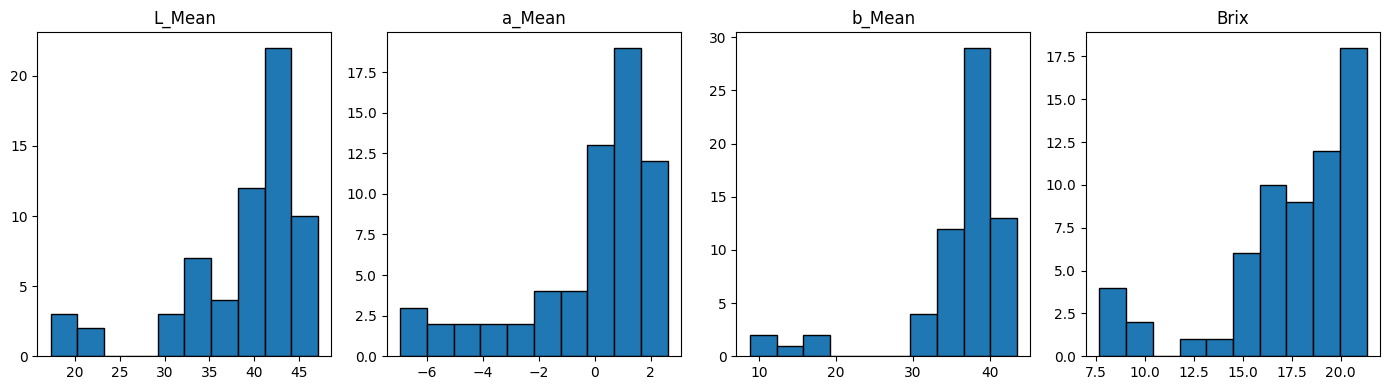

In [ ]:
variables = [
    "L_Mean",
    "a_Mean",
    "b_Mean",
    "Brix"
]

plt.figure(figsize=(14,4))

for i,var in enumerate(variables):

    plt.subplot(1,4,i+1)

    plt.hist(
        dataset[var],
        bins=10,
        edgecolor="black"
    )

    plt.title(var)

plt.tight_layout()

plt.show()

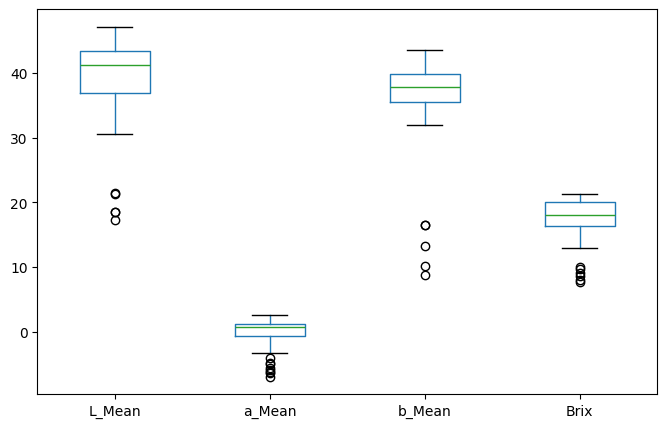

In [ ]:
plt.figure(figsize=(8,5))

dataset[
    [
        "L_Mean",
        "a_Mean",
        "b_Mean",
        "Brix"
    ]
].boxplot()

plt.grid()

plt.show()

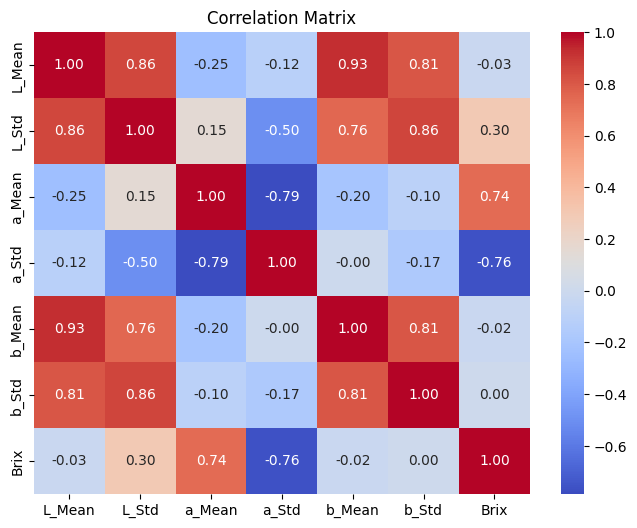

In [ ]:
corr = dataset.corr(
    numeric_only=True
)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

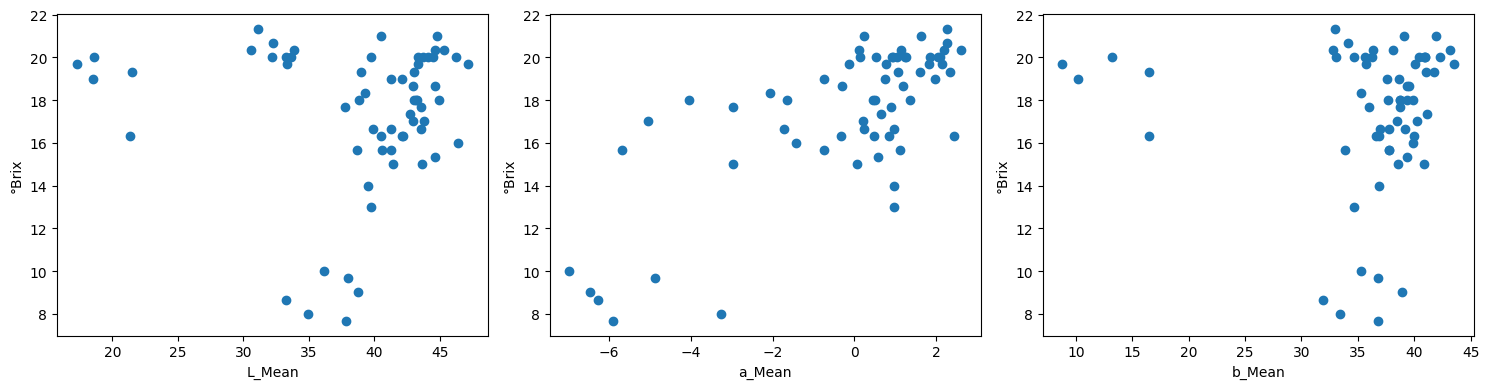

In [ ]:
fig,ax = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

variables = [
    "L_Mean",
    "a_Mean",
    "b_Mean"
]

for i,var in enumerate(variables):

    ax[i].scatter(
        dataset[var],
        dataset["Brix"]
    )

    ax[i].set_xlabel(var)

    ax[i].set_ylabel("°Brix")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# BLOQUE 5
# MATRICES
# ============================================================

X = dataset[
    [
        "L_Mean",
        "L_Std",
        "a_Mean",
        "a_Std",
        "b_Mean",
        "b_Std"
    ]
].values

y = dataset["Brix"].values

print(X.shape)
print(y.shape)

(63, 6)
(63,)


In [ ]:
# ============================================================
# BLOQUE 6
# CONFIGURACIÓN
# ============================================================

RANDOM_STATE = 42

N_SPLITS = 5

N_REPEATS = 10

CV = RepeatedKFold(

    n_splits=N_SPLITS,

    n_repeats=N_REPEATS,

    random_state=RANDOM_STATE

)

print(CV)

RepeatedKFold(n_repeats=10, n_splits=5, random_state=42)


In [ ]:
# ============================================================
# BLOQUE 7
# MÉTRICAS
# ============================================================

def calculate_metrics(y_true, y_pred):

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    r2 = r2_score(y_true, y_pred)

    rmsep = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    bias = np.mean(
        y_pred - y_true
    )

    sep = np.sqrt(
        np.mean(
            ((y_pred - y_true) - bias) ** 2
        )
    )

    rpd = np.std(
        y_true,
        ddof=1
    ) / rmsep

    return {

        "R2": r2,

        "RMSEP": rmsep,

        "MAE": mae,

        "Bias": bias,

        "SEP": sep,

        "RPD": rpd

    }

In [ ]:
# ============================================================
# BLOQUE 8
# PREPROCESADORES
# ============================================================

def preprocess_raw(X_train, X_test):

    return X_train.copy(), X_test.copy()


def preprocess_standard(X_train, X_test):

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    return X_train, X_test


def preprocess_minmax(X_train, X_test):

    scaler = MinMaxScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    return X_train, X_test


def preprocess_robust(X_train, X_test):

    scaler = RobustScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    return X_train, X_test


PREPROCESSORS = {

    "RAW": preprocess_raw,

    "STANDARD": preprocess_standard,

    "MINMAX": preprocess_minmax,

    "ROBUST": preprocess_robust

}

print(PREPROCESSORS.keys())

dict_keys(['RAW', 'STANDARD', 'MINMAX', 'ROBUST'])


In [ ]:
# ============================================================
# BLOQUE 9
# EVALUACIÓN UNIVERSAL
# ============================================================

def evaluate_model(
    model,
    preprocessing,
    X,
    y,
    cv
):

    y_true = []

    y_pred = []

    fold_results = []

    preprocessing_function = PREPROCESSORS[preprocessing]

    for fold, (train_idx, test_idx) in enumerate(cv.split(X), start=1):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        X_train, X_test = preprocessing_function(
            X_train,
            X_test
        )

        mdl = clone(model)

        mdl.fit(
            X_train,
            y_train
        )

        prediction = mdl.predict(X_test)

        prediction = np.asarray(prediction).ravel()

        y_true.extend(y_test)

        y_pred.extend(prediction)

        fold_results.append(

            pd.DataFrame({

                "Fold": fold,

                "Observed": y_test,

                "Predicted": prediction

            })

        )

    y_true = np.array(y_true)

    y_pred = np.array(y_pred)

    metrics = calculate_metrics(
        y_true,
        y_pred
    )

    residuals = y_true - y_pred

    results = pd.concat(
        fold_results,
        ignore_index=True
    )

    return {

        "metrics": metrics,

        "results": results,

        "y_true": y_true,

        "y_pred": y_pred,

        "residuals": residuals

    }

In [ ]:
# ============================================================
# BLOQUE 10
# OPTIMIZACIÓN PLSR
# ============================================================

results_plsr = []

for n_comp in range(1, 7):

    model = PLSRegression(
        n_components=n_comp
    )

    result = evaluate_model(

        model=model,

        preprocessing="STANDARD",

        X=X,

        y=y,

        cv=CV

    )

    results_plsr.append({

        "Components": n_comp,

        **result["metrics"]

    })

plsr_results = pd.DataFrame(results_plsr)

display(plsr_results)

,Components,R2,RMSEP,MAE,Bias,SEP,RPD
0,1,0.568938,2.201276,1.836777,-0.052403,2.200652,1.524317
1,2,0.593072,2.138767,1.749210,0.011509,2.138736,1.568868
2,3,0.596845,2.128830,1.729389,-0.013641,2.128787,1.576190
3,4,0.593127,2.138622,1.777557,-0.044230,2.138165,1.568974
4,5,0.607127,2.101506,1.752940,-0.040280,2.101120,1.596685
5,6,0.623180,2.058126,1.724298,-0.029570,2.057913,1.630339


In [ ]:
best_plsr = plsr_results.sort_values(
    "R2",
    ascending=False
).iloc[0]

best_plsr

,5
Components,6.000000
R2,0.623180
RMSEP,2.058126
MAE,1.724298
Bias,-0.029570
SEP,2.057913
RPD,1.630339


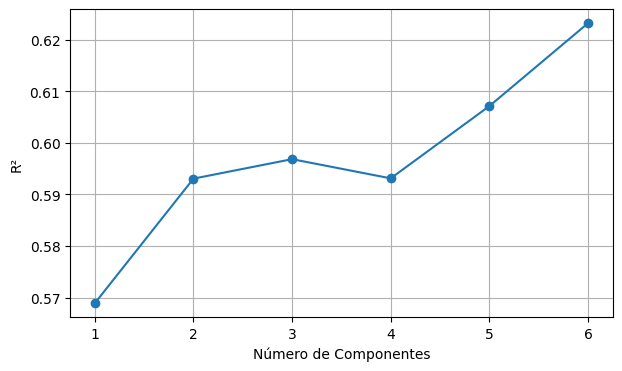

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(

    plsr_results["Components"],

    plsr_results["R2"],

    marker="o"

)

plt.xlabel("Número de Componentes")

plt.ylabel("R²")

plt.grid()

plt.show()

In [ ]:
# ============================================================
# BLOQUE 11
# OPTIMIZACIÓN SVR
# ============================================================

svr_results = []

C_values = [0.1, 1, 10, 25, 50, 100]

gamma_values = [
    "scale",
    0.01,
    0.05,
    0.1,
    0.5
]

for C in C_values:

    for gamma in gamma_values:

        model = SVR(

            kernel="rbf",

            C=C,

            gamma=gamma

        )

        result = evaluate_model(

            model=model,

            preprocessing="STANDARD",

            X=X,

            y=y,

            cv=CV

        )

        svr_results.append({

            "C": C,

            "Gamma": gamma,

            **result["metrics"]

        })

svr_results = pd.DataFrame(svr_results)

svr_results = svr_results.sort_values(

    "R2",

    ascending=False

).reset_index(drop=True)

display(svr_results.head(10))

,C,Gamma,R2,RMSEP,MAE,Bias,SEP,RPD
0,10.0,0.1,0.693324,1.856711,1.466100,0.241032,1.841000,1.807196
1,10.0,0.05,0.690320,1.865785,1.469680,0.268114,1.846420,1.798408
2,25.0,0.05,0.684791,1.882366,1.483708,0.250708,1.865596,1.782566
3,25.0,0.1,0.662401,1.948074,1.503625,0.232489,1.934151,1.722441
4,50.0,0.05,0.661483,1.950721,1.521227,0.263294,1.932870,1.720104
5,10.0,scale,0.660262,1.954234,1.506599,0.230245,1.940623,1.717011
6,50.0,0.1,0.648336,1.988238,1.528427,0.209129,1.977209,1.687646
7,100.0,0.05,0.644113,2.000142,1.548665,0.239828,1.985712,1.677601
8,25.0,scale,0.627223,2.047055,1.563512,0.190242,2.038196,1.639156
9,100.0,0.01,0.625747,2.051104,1.644434,0.280628,2.031816,1.635920


In [ ]:
best_svr = svr_results.iloc[0]

print(best_svr)


C            10.0
Gamma         0.1
R2       0.693324
RMSEP    1.856711
MAE        1.4661
Bias     0.241032
SEP         1.841
RPD      1.807196
Name: 0, dtype: object


In [ ]:
# ============================================================
# BLOQUE 12
# OPTIMIZACIÓN RANDOM FOREST
# ============================================================

rf_results = []

n_estimators_list = [100, 200, 300]

max_depth_list = [5, 10, 15, None]

min_samples_leaf_list = [1, 2, 4]

for n_estimators in n_estimators_list:

    for max_depth in max_depth_list:

        for min_samples_leaf in min_samples_leaf_list:

            model = RandomForestRegressor(

                n_estimators=n_estimators,

                max_depth=max_depth,

                min_samples_leaf=min_samples_leaf,

                random_state=RANDOM_STATE,

                n_jobs=-1

            )

            result = evaluate_model(

                model=model,

                preprocessing="RAW",   # RF no necesita escalado

                X=X,

                y=y,

                cv=CV

            )

            rf_results.append({

                "Trees": n_estimators,

                "Depth": max_depth,

                "Leaf": min_samples_leaf,

                **result["metrics"]

            })

rf_results = pd.DataFrame(rf_results)

rf_results = rf_results.sort_values(

    "R2",

    ascending=False

).reset_index(drop=True)

display(rf_results.head(10))

,Trees,Depth,Leaf,R2,RMSEP,MAE,Bias,SEP,RPD
0,300,5.0,2,0.702625,1.828342,1.475694,-0.042789,1.827841,1.835238
1,200,5.0,2,0.701801,1.830870,1.479178,-0.045296,1.830310,1.832704
2,200,5.0,1,0.701684,1.831231,1.493692,-0.098062,1.828603,1.832343
3,300,5.0,1,0.701018,1.833275,1.491625,-0.093062,1.830911,1.830299
4,100,5.0,2,0.700760,1.834064,1.482855,-0.050914,1.833358,1.829511
5,100,5.0,1,0.699280,1.838593,1.500075,-0.100194,1.835861,1.825005
6,300,15.0,2,0.697514,1.843985,1.486946,-0.045260,1.843430,1.819669
7,300,NaN,2,0.697514,1.843985,1.486946,-0.045260,1.843430,1.819669
8,300,10.0,2,0.697507,1.844006,1.486955,-0.045241,1.843451,1.819648
9,200,NaN,2,0.696514,1.847030,1.490127,-0.047450,1.846421,1.816668


In [ ]:
best_rf = rf_results.iloc[0]

print(best_rf)

Trees    300.000000
Depth      5.000000
Leaf       2.000000
R2         0.702625
RMSEP      1.828342
MAE        1.475694
Bias      -0.042789
SEP        1.827841
RPD        1.835238
Name: 0, dtype: float64


In [ ]:
# ============================================================
# BLOQUE 13A
# OPTIMIZACIÓN PRINCIPAL XGBOOST
# ============================================================

xgb_stage1 = []

learning_rates = [0.03, 0.05, 0.08, 0.10]

max_depths = [3, 4, 5, 6]

n_estimators_list = [100, 200, 300, 400]

for lr in learning_rates:

    for depth in max_depths:

        for trees in n_estimators_list:

            model = XGBRegressor(

                learning_rate=lr,

                max_depth=depth,

                n_estimators=trees,

                objective="reg:squarederror",

                random_state=RANDOM_STATE,

                verbosity=0

            )

            result = evaluate_model(

                model=model,

                preprocessing="RAW",

                X=X,

                y=y,

                cv=CV

            )

            xgb_stage1.append({

                "LearningRate": lr,

                "Depth": depth,

                "Trees": trees,

                **result["metrics"]

            })

xgb_stage1 = pd.DataFrame(xgb_stage1)

xgb_stage1 = xgb_stage1.sort_values(

    "R2",

    ascending=False

).reset_index(drop=True)

display(xgb_stage1.head(10))

,LearningRate,Depth,Trees,R2,RMSEP,MAE,Bias,SEP,RPD
0,0.03,3,100,0.578828,2.175877,1.666859,0.084289,2.174244,1.542110
1,0.05,3,100,0.568445,2.202534,1.692145,0.069386,2.201441,1.523446
2,0.03,3,200,0.566485,2.207532,1.696353,0.061535,2.206674,1.519997
3,0.08,3,100,0.551217,2.246068,1.727559,0.056257,2.245364,1.493918
4,0.03,3,300,0.551084,2.246401,1.726792,0.058469,2.245640,1.493697
5,0.10,3,100,0.547691,2.254875,1.733764,0.047405,2.254377,1.488083
6,0.03,4,100,0.545026,2.261508,1.714809,0.095353,2.259497,1.483719
7,0.05,3,200,0.543524,2.265239,1.739938,0.066087,2.264274,1.481275
8,0.03,3,400,0.541403,2.270495,1.745734,0.057605,2.269764,1.477846
9,0.03,4,200,0.540180,2.273521,1.730479,0.063143,2.272644,1.475879


In [ ]:
best_stage1 = xgb_stage1.iloc[0]

print(best_stage1)

LearningRate      0.030000
Depth             3.000000
Trees           100.000000
R2                0.578828
RMSEP             2.175877
MAE               1.666859
Bias              0.084289
SEP               2.174244
RPD               1.542110
Name: 0, dtype: float64


In [ ]:
# ============================================================
# BLOQUE 13B
# AJUSTE FINO XGBOOST
# ============================================================

xgb_stage2 = []

subsamples = [0.8, 0.9, 1.0]

min_child_weights = [1, 2, 3]

colsample_values = [0.7, 0.85, 1.0]

for subsample in subsamples:

    for child in min_child_weights:

        for colsample in colsample_values:

            model = XGBRegressor(

                learning_rate=float(best_stage1["LearningRate"]),

                max_depth=int(best_stage1["Depth"]),

                n_estimators=int(best_stage1["Trees"]),

                subsample=subsample,

                min_child_weight=child,

                colsample_bytree=colsample,

                objective="reg:squarederror",

                random_state=RANDOM_STATE,

                verbosity=0

            )

            result = evaluate_model(

                model=model,

                preprocessing="RAW",

                X=X,

                y=y,

                cv=CV

            )

            xgb_stage2.append({

                "Subsample": subsample,

                "MinChildWeight": child,

                "Colsample": colsample,

                **result["metrics"]

            })

xgb_stage2 = pd.DataFrame(xgb_stage2)

xgb_stage2 = xgb_stage2.sort_values(

    "R2",

    ascending=False

).reset_index(drop=True)

display(xgb_stage2.head(10))

,Subsample,MinChildWeight,Colsample,R2,RMSEP,MAE,Bias,SEP,RPD
0,1.0,1,0.70,0.610421,2.092678,1.633189,0.091617,2.090672,1.603420
1,0.8,3,0.70,0.609325,2.095621,1.606790,0.032859,2.095363,1.601168
2,0.8,1,0.70,0.607327,2.100973,1.611680,0.063716,2.100007,1.597089
3,0.9,1,0.70,0.606743,2.102533,1.620379,0.064482,2.101544,1.595904
4,0.8,2,0.70,0.606696,2.102658,1.605692,0.049322,2.102080,1.595809
5,1.0,1,0.85,0.601314,2.116997,1.638480,0.100391,2.114615,1.585001
6,0.9,3,0.70,0.601265,2.117128,1.602628,0.048837,2.116564,1.584903
7,0.9,2,0.70,0.598734,2.123836,1.616177,0.062342,2.122921,1.579897
8,1.0,2,0.70,0.598246,2.125127,1.628238,0.091948,2.123137,1.578937
9,0.8,1,0.85,0.597163,2.127989,1.622822,0.059799,2.127149,1.576813


In [ ]:
best_xgb = xgb_stage2.iloc[0]

BEST_XGB = XGBRegressor(

    learning_rate=float(best_stage1["LearningRate"]),

    max_depth=int(best_stage1["Depth"]),

    n_estimators=int(best_stage1["Trees"]),

    subsample=float(best_xgb["Subsample"]),

    min_child_weight=int(best_xgb["MinChildWeight"]),

    colsample_bytree=float(best_xgb["Colsample"]),

    objective="reg:squarederror",

    random_state=RANDOM_STATE,

    verbosity=0

)

print(BEST_XGB)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


In [ ]:
BEST_PLSR = PLSRegression(
    n_components=6
)

BEST_SVR = SVR(
    kernel="rbf",
    C=10,
    gamma=0.1
)

BEST_RF = RandomForestRegressor(

    n_estimators=300,

    max_depth=5,

    min_samples_leaf=2,

    random_state=RANDOM_STATE,

    n_jobs=-1
)

BEST_XGB = XGBRegressor(

    learning_rate=float(best_stage1["LearningRate"]),

    max_depth=int(best_stage1["Depth"]),

    n_estimators=int(best_stage1["Trees"]),

    subsample=float(best_xgb["Subsample"]),

    min_child_weight=int(best_xgb["MinChildWeight"]),

    colsample_bytree=float(best_xgb["Colsample"]),

    objective="reg:squarederror",

    random_state=RANDOM_STATE,

    verbosity=0
)

In [ ]:
models = {

    "PLSR": (BEST_PLSR, "STANDARD"),

    "SVR": (BEST_SVR, "STANDARD"),

    "RF": (BEST_RF, "RAW"),

    "XGBoost": (BEST_XGB, "RAW")

}

summary = []

all_results = {}

for name, (model, prep) in models.items():

    result = evaluate_model(

        model=model,

        preprocessing=prep,

        X=X,

        y=y,

        cv=CV

    )

    all_results[name] = result

    summary.append({

        "Model": name,

        **result["metrics"]

    })

summary = pd.DataFrame(summary)

summary = summary.sort_values(

    "R2",

    ascending=False

).reset_index(drop=True)

display(summary)

,Model,R2,RMSEP,MAE,Bias,SEP,RPD
0,RF,0.702625,1.828342,1.475694,-0.042789,1.827841,1.835238
1,SVR,0.693324,1.856711,1.466100,0.241032,1.841000,1.807196
2,PLSR,0.623180,2.058126,1.724298,-0.029570,2.057913,1.630339
3,XGBoost,0.610421,2.092678,1.633189,0.091617,2.090672,1.603420


In [ ]:
models = {
    "PLSR": BEST_PLSR,
    "SVR": BEST_SVR,
    "RF": BEST_RF,
    "XGBoost": BEST_XGB
}

results = []

for prep in PREPROCESSORS.keys():

    for name, model in models.items():

        result = evaluate_model(
            model=model,
            preprocessing=prep,
            X=X,
            y=y,
            cv=CV
        )

        results.append({

            "Model": name,

            "Preprocessing": prep,

            **result["metrics"]

        })

results = pd.DataFrame(results)

results = results.sort_values(
    "R2",
    ascending=False
)

display(results)

,Model,Preprocessing,R2,RMSEP,MAE,Bias,SEP,RPD
2,RF,RAW,0.702625,1.828342,1.475694,-0.042789,1.827841,1.835238
14,RF,ROBUST,0.702625,1.828342,1.475694,-0.042789,1.827841,1.835238
10,RF,MINMAX,0.702625,1.828342,1.475694,-0.042789,1.827841,1.835238
6,RF,STANDARD,0.702625,1.828342,1.475694,-0.042789,1.827841,1.835238
5,SVR,STANDARD,0.693324,1.856711,1.466100,0.241032,1.841000,1.807196
13,SVR,ROBUST,0.641117,2.008545,1.546490,0.283087,1.988495,1.670584
8,PLSR,MINMAX,0.623180,2.058126,1.724298,-0.029570,2.057913,1.630339
0,PLSR,RAW,0.623180,2.058126,1.724298,-0.029570,2.057913,1.630339
12,PLSR,ROBUST,0.623180,2.058126,1.724298,-0.029570,2.057913,1.630339
4,PLSR,STANDARD,0.623180,2.058126,1.724298,-0.029570,2.057913,1.630339


In [ ]:
results.to_excel(
    "Resultados_Colorimetria.xlsx",
    index=False
)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


In [ ]:
# ============================================================
# BLOQUE FINAL
# EXPORTAR MODELO DEFINITIVO
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
import joblib

pipeline = Pipeline([

    ("scaler", RobustScaler()),

    ("model", RandomForestRegressor(

        n_estimators=300,

        max_depth=5,

        min_samples_leaf=2,

        random_state=RANDOM_STATE,

        n_jobs=-1

    ))

])

pipeline.fit(X, y)

joblib.dump(

    pipeline,

    "color_banana_pipeline.pkl"

)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


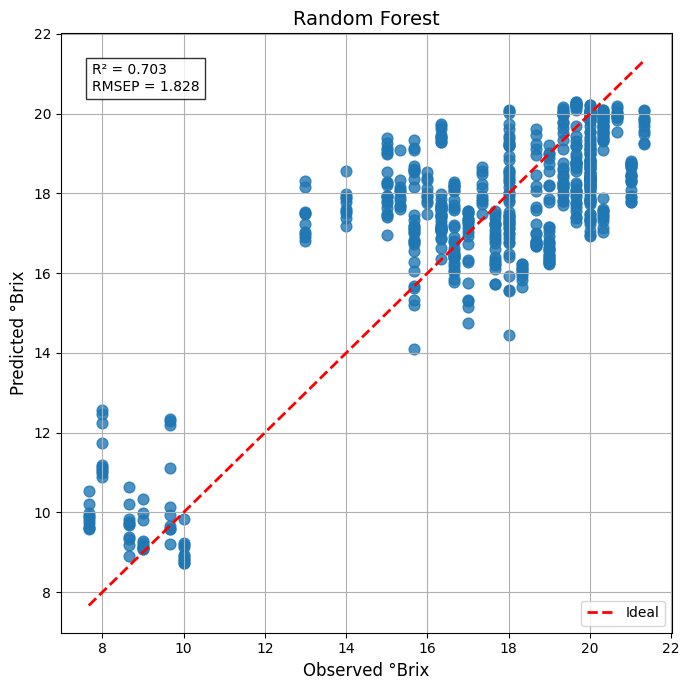

In [ ]:
# ============================================================
# BLOQUE 15
# OBSERVED VS PREDICTED
# ============================================================

best_result = all_results["RF"]

y_true = best_result["y_true"]
y_pred = best_result["y_pred"]

r2 = best_result["metrics"]["R2"]
rmsep = best_result["metrics"]["RMSEP"]

plt.figure(figsize=(7,7))

plt.scatter(
    y_true,
    y_pred,
    s=60,
    alpha=0.8
)

# Línea identidad
lims = [

    min(y_true.min(), y_pred.min()),

    max(y_true.max(), y_pred.max())

]

plt.plot(
    lims,
    lims,
    'r--',
    linewidth=2,
    label="Ideal"
)

plt.xlabel("Observed °Brix", fontsize=12)

plt.ylabel("Predicted °Brix", fontsize=12)

plt.title("Random Forest", fontsize=14)

plt.text(

    0.05,

    0.95,

    f"R² = {r2:.3f}\nRMSEP = {rmsep:.3f}",

    transform=plt.gca().transAxes,

    verticalalignment="top",

    bbox=dict(facecolor="white", alpha=0.8)

)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

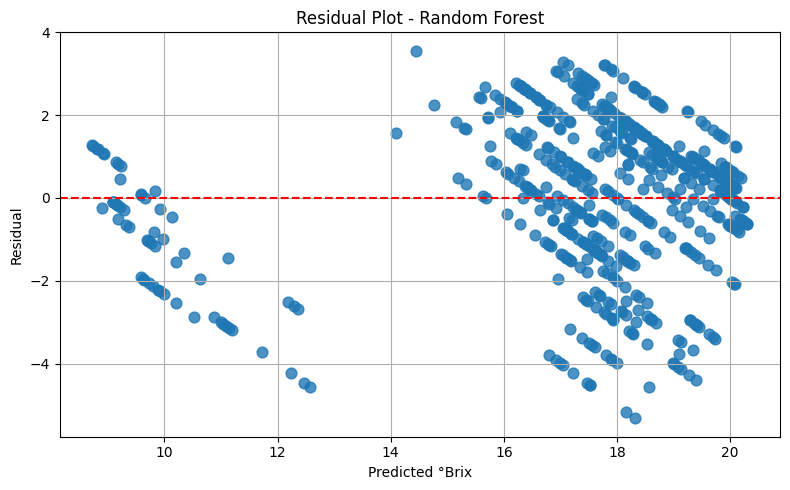

In [ ]:
# ============================================================
# BLOQUE 16
# RESIDUAL PLOT
# ============================================================

residuals = y_true - y_pred

plt.figure(figsize=(8,5))

plt.scatter(

    y_pred,

    residuals,

    s=60,

    alpha=0.8

)

plt.axhline(

    0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted °Brix")

plt.ylabel("Residual")

plt.title("Residual Plot - Random Forest")

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# BLOQUE 17
# FEATURE IMPORTANCE
# ============================================================

BEST_RF.fit(X, y)

importance = pd.DataFrame({

    "Variable":[

        "L_Mean",

        "L_Std",

        "a_Mean",

        "a_Std",

        "b_Mean",

        "b_Std"

    ],

    "Importance":BEST_RF.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

display(importance)

,Variable,Importance
3,a_Std,0.703212
2,a_Mean,0.157620
5,b_Std,0.046633
4,b_Mean,0.036657
0,L_Mean,0.029399
1,L_Std,0.026478


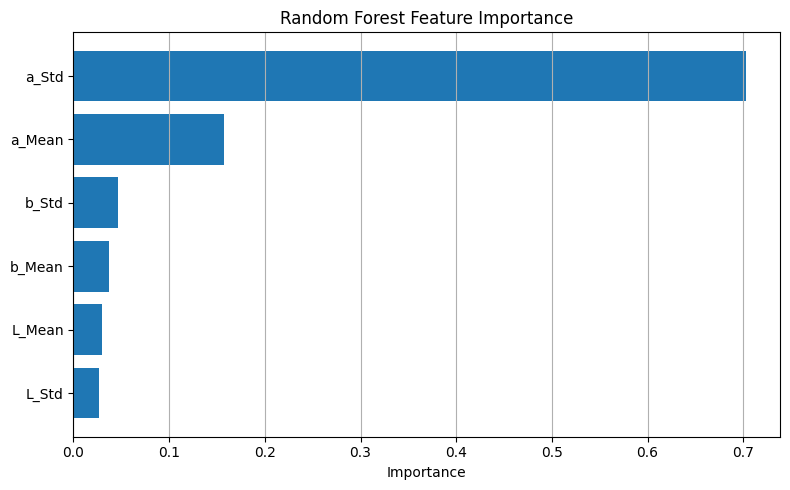

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(

    importance["Variable"],

    importance["Importance"]

)

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.tight_layout()

plt.show()

In [ ]:
importance["Importance (%)"] = (

    importance["Importance"]

    /

    importance["Importance"].sum()

)*100

display(importance)

,Variable,Importance,Importance (%)
3,a_Std,0.703212,70.321201
2,a_Mean,0.157620,15.762018
5,b_Std,0.046633,4.663341
4,b_Mean,0.036657,3.665700
0,L_Mean,0.029399,2.939893
1,L_Std,0.026478,2.647848


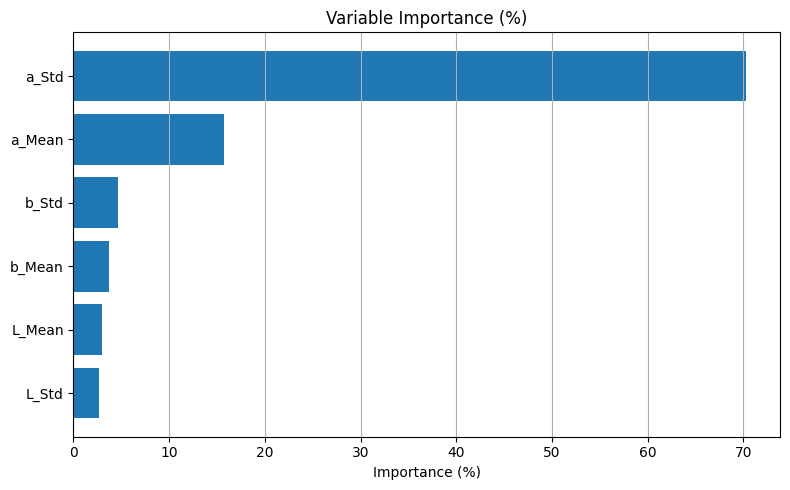

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(

    importance["Variable"],

    importance["Importance (%)"]

)

plt.xlabel("Importance (%)")

plt.title("Variable Importance (%)")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.tight_layout()

plt.show()

In [ ]:
corr = dataset[
    [
        "L_Mean",
        "L_Std",
        "a_Mean",
        "a_Std",
        "b_Mean",
        "b_Std",
        "Brix"
    ]
].corr()

corr["Brix"].sort_values()

,Brix
a_Std,-0.761991
L_Mean,-0.025652
b_Mean,-0.023906
b_Std,0.003776
L_Std,0.297776
a_Mean,0.740576
Brix,1.000000


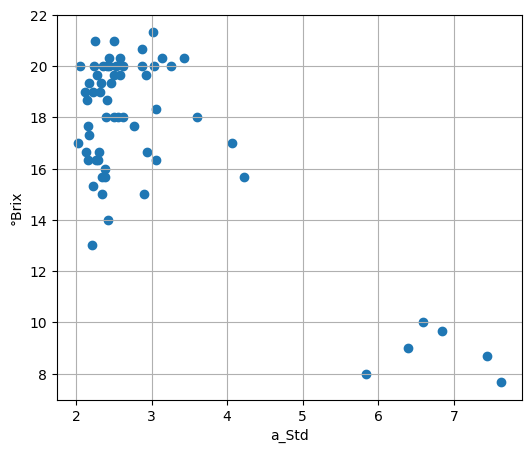

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(
    dataset["a_Std"],
    dataset["Brix"]
)

plt.xlabel("a_Std")

plt.ylabel("°Brix")

plt.grid()

plt.show()